#문제2에 사용할 이미지를 만들기 위해 필요한 함수(문제 1 함수와 동일)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from scipy.fftpack import dct, idct
from scipy.ndimage import zoom
from google.colab import drive
drive.mount('/content/drive')

def process_horizontal(img):
    H, W, C = img.shape
    I_A = np.zeros((H, W // 2, C), dtype=np.int32)
    I_B = np.zeros((H, W // 2, C), dtype=np.int32)

    for c in range(C):  # 각 색상 채널 (R, G, B)
        for y in range(H):
            for x in range(0, W, 2):
                I_A[y, x // 2, c] = img[y, x, c] + img[y, x + 1, c]
                I_B[y, x // 2, c] = img[y, x, c] - img[y, x + 1, c]

    return I_A, I_B

def process_vertical(img):
    H, W, C = img.shape
    I_C = np.zeros((H // 2, W, C), dtype=np.int32)
    I_D = np.zeros((H // 2, W, C), dtype=np.int32)

    for c in range(C):
        for y in range(0, H, 2):
            for x in range(W):
                I_C[y // 2, x, c] = img[y, x, c] + img[y + 1, x, c]
                I_D[y // 2, x, c] = img[y, x, c] - img[y + 1, x, c]
    return I_C, I_D


# 가로 방향 처리 복원
def restore_horizontal(I_A, I_B):
    H, W_half, C = I_A.shape
    W = W_half * 2
    restored = np.zeros((H, W, C), dtype=np.int32)

    for c in range(C):
        for y in range(H):
            for x in range(W_half):
                restored[y, 2 * x, c] = (I_A[y, x, c] + I_B[y, x, c]) // 2
                restored[y, 2 * x + 1, c] = (I_A[y, x, c] - I_B[y, x, c]) // 2
    return restored

# 세로 방향 처리 복원
def restore_image_vertical(I_C, I_D):
    H_half, W, C = I_C.shape
    H = H_half * 2
    restored = np.zeros((H, W, C), dtype=np.int32)

    for c in range(C):
        for x in range(W):
            for y in range(H_half):
                restored[2 * y, x, c] = (I_C[y, x, c] + I_D[y, x, c]) // 2
                restored[2 * y + 1, x, c] = (I_C[y, x, c] - I_D[y, x, c]) // 2
    return restored

    # MSE 계산 함수
def calculate_mse(original, restored):
    return np.mean((original - restored) ** 2)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#문제2에서 사용할 이미지 생성

In [ ]:
# 이미지 로드 및 변환 (RGB 이미지)
image = cv2.imread('/content/drive/My Drive/Colab Notebooks/lena.bmp', cv2.IMREAD_COLOR)
image_yuv = cv2.cvtColor(image, cv2.COLOR_BGR2YUV).astype(np.float32)  # 연산 전에 int32로 변환해야 overflow 발생 안함

# 세로방향 3단계 후 가로 방향 3단계 적용
# 세로 방향 3단계
I_A1, I_B1 = process_vertical(image_yuv)
I_A2_A, I_A2_B = process_vertical(I_A1)
I_B2_A, I_B2_B = process_vertical(I_B1)
I_A3_AA, I_A3_AB = process_vertical(I_A2_A)
I_A3_BA, I_A3_BB = process_vertical(I_A2_B)
I_B3_AA, I_B3_AB = process_vertical(I_B2_A)
I_B3_BA, I_B3_BB = process_vertical(I_B2_B)

vertical_images = [
    I_A3_AA, I_A3_AB, I_A3_BA, I_A3_BB,
    I_B3_AA, I_B3_AB, I_B3_BA, I_B3_BB
]

# 가로 방향 3단계 진행
horizontal_final_results = []
for img in vertical_images:
    # 1단계
    V1, V2 = process_horizontal(img)
    # 2단계
    V3, V4 = process_horizontal(V1)
    V5, V6 = process_horizontal(V2)

    # 3단계
    V7, V8 = process_horizontal(V3)
    V9, V10 = process_horizontal(V4)
    V11, V12 = process_horizontal(V5)
    V13, V14 = process_horizontal(V6)
    horizontal_final_results.extend([V7, V8, V9, V10, V11, V12, V13, V14])

# image_list는 '(64*64)크기 YUV 이미지 64개'가 있는 '리스트'
image_list = horizontal_final_results


# 문제 2에 사용할 함수


압축에 필요한 함수

In [1]:
# 양자화 수행
def quantize(image, quant_table, QP):
    quant_table = quant_table * QP
    return np.round(image / quant_table).astype(int)

# 양자화 테이블 64x64
luminance_quant_table = np.ones((64, 64))
chrominance_quant_table = np.ones((64, 64))

# Zig-Zag 재배열
def zigzag(image):
    rows, cols = image.shape
    result = []
    for d in range(rows + cols - 1):
        if d % 2 == 1:  # 홀수 대각선: 아래에서 위로
            for i in range(max(0, d - cols + 1), min(d + 1, rows)):
                result.append(image[i, d - i])
        else:  # 짝수 대각선: 위에서 아래로
            for i in range(max(0, d - rows + 1), min(d + 1, cols)):
                result.append(image[d - i, i])
    return np.array(result)

# Unary 코딩
def unary_encode(zigzag_result):
    unary_encoded = []
    for value in zigzag_result:
        if value >= 0:
            unary_encoded.append('1' * value + '0')
        else:
            unary_encoded.append('1' * abs(value) + '0' + '-')
    return unary_encoded

# Y 이미지 양자화, Zig-Zag 재배열, Unary
def image_compress(image, quant_table, QP):

    image = quantize(image, quant_table, QP)   # 양자화 수행
    zigzag_result = zigzag(image)              # Zig-Zag 재배열
    unary_result = unary_encode(zigzag_result) # unary 코딩

    return unary_result # 리스트 형태

NameError: name 'np' is not defined

복원에 필요한 함수

In [2]:
# 양자화 역변환
def dequantize(quantized_image, quant_table, QP):
    adjusted_quant_table = quant_table * QP
    return (quantized_image * adjusted_quant_table).astype(float)

# Zig-Zag 역재배열
def inverse_zigzag(arr):

    result = np.zeros((64, 64), dtype=float)
    index = 0

    for d in range(64 + 64 - 1):
        if d % 2 == 1:  # 홀수 대각선: 아래에서 위로
            for i in range(max(0, d - 64 + 1), min(d + 1, 64)):
                result[i, d - i] = arr[index]
                index += 1
        else:  # 짝수 대각선: 위에서 아래로
            for i in range(max(0, d - 64 + 1), min(d + 1, 64)):
                result[d - i, i] = arr[index]
                index += 1
    return result

# Unary 디코딩
def unary_decode(compressed_image):
    decoded = []
    for code in compressed_image:
        if code.endswith('-'):
            value = -len(code[:-1].rstrip('0'))
        else:
            value = len(code.rstrip('0'))
        decoded.append(value)
    return np.array(decoded)

# 압축된 결과로부터 원본 이미지 복원
def image_decompress(compressed_image, quant_table, QP):
    zigzag_result = unary_decode(compressed_image)# Unary 디코딩
    dezigzagged = inverse_zigzag(zigzag_result)# Zig-Zag 역재배열
    restored_image = dequantize(dezigzagged, quant_table, QP)  # 양자화 역변환

    return restored_image

#문제 2_A 코드

In [ ]:
# 원본과 압축-복원 이미지의 MSE 및 총 비트
restored_image_list = []
size = 0

for i, image in enumerate(image_list):
  QP = 100
  compressed_image_Y = image_compress(image[:,:,0], luminance_quant_table, QP)
  compressed_image_U = image_compress(image[:,:,1], chrominance_quant_table, QP)
  compressed_image_V = image_compress(image[:,:,2], chrominance_quant_table, QP)

  decompressed_image_Y = image_decompress(compressed_image_Y, luminance_quant_table, QP)
  decompressed_image_U = image_decompress(compressed_image_U, chrominance_quant_table, QP)
  decompressed_image_V = image_decompress(compressed_image_V, chrominance_quant_table, QP)

  final_image = np.stack((decompressed_image_Y, decompressed_image_U, decompressed_image_V), axis=2)
  restored_image_list.append(final_image)

  mse_value = calculate_mse(image, final_image)
  total_bits = sum(len(code) for code in compressed_image_Y) + sum(len(code) for code in compressed_image_U) + sum(len(code) for code in compressed_image_V)
  rate = total_bits / 4096  # 64*64
  size = size + total_bits

  print(f"\n{i+1} rate: {rate}")
  print(f"{i+1} image Distortion: {mse_value}")
  # print(f"{i+1} Total bits:", total_bits)


print(f"\nTotal number of bits in unary encoded list:", size)

# MSE 계산
def calculate_list_mse(list1, list2):
    list1 = np.array(list1)
    list2 = np.array(list2)
    mse = np.mean((list1 - list2) ** 2)
    return mse

mse = calculate_list_mse(restored_image_list, image_list)
print(f"MSE: {mse}")
print(f"rate: {size/262144}")


1 rate: 271.878173828125
1 image Distortion: 833.1443684895834

2 rate: 8.87841796875
2 image Distortion: 794.44775390625

3 rate: 6.029541015625
3 image Distortion: 737.1905924479166

4 rate: 5.674072265625
4 image Distortion: 691.91064453125

5 rate: 4.49658203125
5 image Distortion: 644.0861002604166

6 rate: 4.24951171875
6 image Distortion: 615.88427734375

7 rate: 3.955322265625
7 image Distortion: 563.9786783854166

8 rate: 4.00830078125
8 image Distortion: 581.6726888020834

9 rate: 6.419677734375
9 image Distortion: 742.6935221354166

10 rate: 5.275634765625
10 image Distortion: 649.41552734375

11 rate: 4.178955078125
11 image Distortion: 568.29443359375

12 rate: 4.44580078125
12 image Distortion: 572.5450846354166

13 rate: 3.49755859375
13 image Distortion: 496.4920247395833

14 rate: 3.7021484375
14 image Distortion: 522.3839518229166

15 rate: 3.6611328125
15 image Distortion: 507.99658203125

16 rate: 3.716064453125
16 image Distortion: 509.6853841145833

17 rate: 4.65

#문제 2_B 코드(JPEG 코드는 다른 파일에 있음)

139 666.7803535461426 6.505405426025391
160 765.6459147135416 6.01904296875
192 910.3955078125 5.491062164306641
240 1125.236572265625 4.970531463623047
310 1429.5825805664062 4.506217956542969
450 2032.8804626464844 4.018638610839844


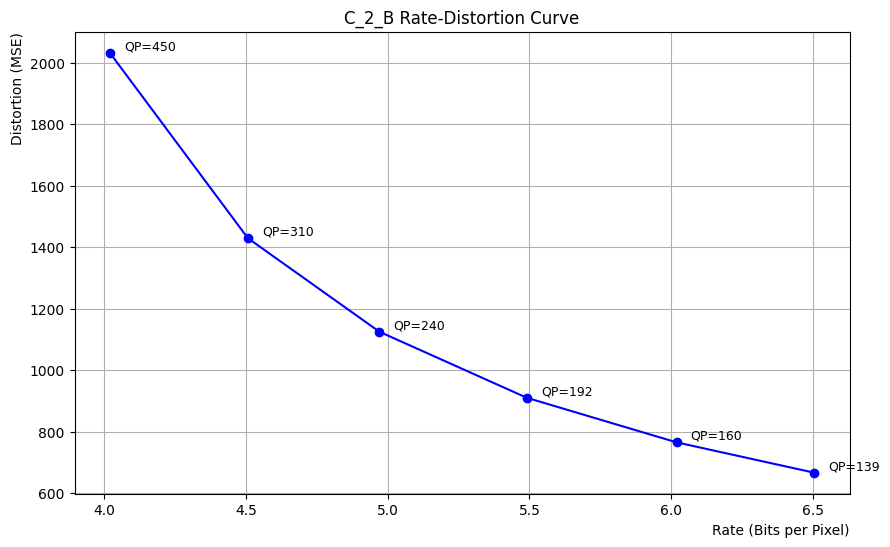

In [ ]:
# 원본과 압축-복원 이미지의 distortion 및 총 비트
size = 0
QP_values = [139, 160, 192, 240, 310, 450]
rate_list = []
distortion_list = []

for qp in QP_values:
    restored_image_list = []
    size = 0

    # 각 블록에 대해 압축, 복원, 비트 수 계산 수행, table만 바꿔서 해보기
    for i, image in enumerate(image_list):
        compressed_image_Y = image_compress(image[:, :, 0], luminance_quant_table, QP=qp)
        compressed_image_U = image_compress(image[:, :, 1], chrominance_quant_table, QP=qp)
        compressed_image_V = image_compress(image[:, :, 2], chrominance_quant_table, QP=qp)

        decompressed_image_Y = image_decompress(compressed_image_Y, luminance_quant_table, QP=qp)
        decompressed_image_U = image_decompress(compressed_image_U, chrominance_quant_table, QP=qp)
        decompressed_image_V = image_decompress(compressed_image_V, chrominance_quant_table, QP=qp)

        final_image = np.stack((decompressed_image_Y, decompressed_image_U, decompressed_image_V), axis=2)
        restored_image_list.append(final_image)

        # 총 비트 수 계산 (압축된 데이터 크기)
        total_bits = sum(len(code) for code in compressed_image_Y) + sum(len(code) for code in compressed_image_U) + sum(len(code) for code in compressed_image_V)
        size += total_bits

    # MSE 계산
    mse_value = calculate_list_mse(image_list, restored_image_list)
    distortion_list.append(mse_value)

    # Rate 계산 (총 비트 수 / 총 픽셀 수)
    rate = size / 262144  # 512 * 512
    rate_list.append(rate)

    print(qp, mse_value, rate)

# 결과 시각화
plt.figure(figsize=(10, 6))
plt.plot(rate_list, distortion_list, marker='o', linestyle='-', color='b')

# 각 포인트에 QP 값 표시
for i, qp in enumerate(QP_values):
    plt.text(rate_list[i]+0.05, distortion_list[i]+0.05, f'QP={qp}', fontsize=9, ha='left', va='bottom')

plt.xlabel('Rate (Bits per Pixel)', loc = 'right')
plt.ylabel('Distortion (MSE)',loc = 'top')
plt.title('C_2_B Rate-Distortion Curve')
plt.grid(True)
plt.show()

# 문제 C 코드

In [ ]:
######################### 최적의 QP 값 찾기 ###########################
optimal_qp_lumi = np.zeros(len(image_list))
optimal_qp_ch = np.zeros(len(image_list))

alpha = 0.05  # MSE 중요도
beta = 0.95   # Rate 중요도

for j in range (len(image_list)):
  min_cost = float('inf')
  optimal_qp = None

  for i, QP in enumerate(range(1, 300, 1)):
      compressed_image_Y = image_compress(image_list[j][:,:,0], luminance_quant_table, QP)
      decompressed_image_Y = image_decompress(compressed_image_Y, luminance_quant_table, QP)

      mse_value = calculate_mse(image_list[j][:,:,0], decompressed_image_Y)
      total_bits = sum(len(code) for code in compressed_image_Y)
      rate = total_bits / 4096  # 64*64

    # 비용 함수 계산
      cost = alpha * mse_value + beta * rate

      if cost < min_cost:
          min_cost = cost
          optimal_qp = QP


  optimal_qp_lumi[j] = optimal_qp
print(optimal_qp_lumi)

for j in range (len(image_list)):
  min_cost = float('inf')
  optimal_qp = None

  for i, QP in enumerate(range(1, 300, 1)):
      compressed_image_Y = image_compress(image_list[j][:,:,1], luminance_quant_table, QP)
      decompressed_image_Y = image_decompress(compressed_image_Y, luminance_quant_table, QP)

      mse_value = calculate_mse(image_list[j][:,:,1], decompressed_image_Y)
      total_bits = sum(len(code) for code in compressed_image_Y)
      rate = total_bits / 4096  # 64*64

    # 비용 함수 계산
      cost = alpha * mse_value + beta * rate

      if cost < min_cost:
          min_cost = cost
          optimal_qp = QP


  optimal_qp_ch[j] = optimal_qp
print(optimal_qp_ch)

[95. 35. 26. 27. 21. 20. 20. 20. 28. 26. 19. 21. 16. 18. 17. 19. 22. 21.
 17. 19. 15. 16. 16. 16. 21. 21. 19. 20. 15. 16. 17. 18. 18. 16. 14. 15.
 12. 14. 13. 14. 17. 17. 14. 15. 14. 14. 14. 14. 16. 16. 15. 16. 13. 14.
 16. 16. 17. 17. 16. 17. 14. 15. 15. 14.]
[99. 21. 17. 16. 14. 14. 14. 14. 18. 16. 14. 14. 14. 13. 13. 14. 15. 14.
 13. 13. 12. 12. 12. 12. 14. 15. 13. 14. 12. 13. 13. 12. 12. 12. 12. 12.
 12. 12. 12. 12. 12. 12. 12. 12. 12. 12. 12. 12. 12. 12. 12. 12. 12. 12.
 12. 12. 12. 12. 12. 12. 12. 12. 12. 12.]


3.1 287.15304223378513 6.5186004638671875
3.5 360.3002519607544 6.029563903808594
4 457.5230712890625 5.559825897216797
5 669.8599217732748 4.927913665771484
6 917.1335144042969 4.513587951660156
7.7 1384.1360028330482 4.093723297119141


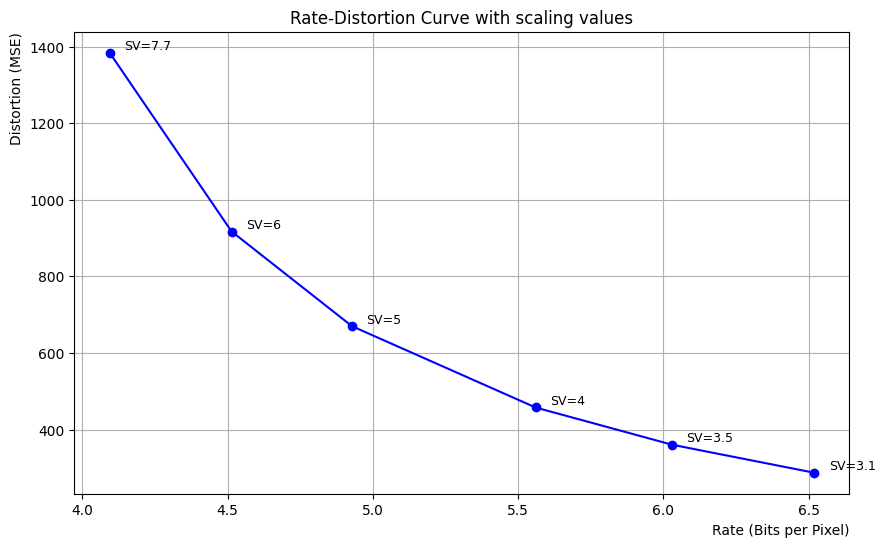

In [ ]:
###### 구한 QP 값들의 scale을 조절하여 R_D curve 얻기#################
size = 0
scaling_values = [3.1, 3.5, 4, 5, 6, 7.7]
rate_list = []
distortion_list = []

for sv in scaling_values:
    restored_image_list = []
    size = 0

    # 각 블록에 대해 압축, 복원, 비트 수 계산 수행, table만 바꿔서 해보기
    for i, image in enumerate(image_list):
        QP_lumi = optimal_qp_lumi[i]*sv
        QP_ch =  optimal_qp_ch[i]*sv

        compressed_image_Y = image_compress(image[:, :, 0], luminance_quant_table, QP_lumi)
        compressed_image_U = image_compress(image[:, :, 1], chrominance_quant_table, QP_ch)
        compressed_image_V = image_compress(image[:, :, 2], chrominance_quant_table, QP_ch)

        decompressed_image_Y = image_decompress(compressed_image_Y, luminance_quant_table, QP_lumi)
        decompressed_image_U = image_decompress(compressed_image_U, chrominance_quant_table, QP_ch)
        decompressed_image_V = image_decompress(compressed_image_V, chrominance_quant_table, QP_ch)

        final_image = np.stack((decompressed_image_Y, decompressed_image_U, decompressed_image_V), axis=2)
        restored_image_list.append(final_image)

        # 총 비트 수 계산 (압축된 데이터 크기)
        total_bits = sum(len(code) for code in compressed_image_Y) + sum(len(code) for code in compressed_image_U) + sum(len(code) for code in compressed_image_V)
        size += total_bits

    # MSE 계산
    mse_value = calculate_list_mse(image_list, restored_image_list)
    distortion_list.append(mse_value)

    # Rate 계산 (총 비트 수 / 총 픽셀 수)
    rate = size / 262144  # 512 * 512
    rate_list.append(rate)

    print(sv, mse_value, rate)

# 결과 시각화
plt.figure(figsize=(10, 6))
plt.plot(rate_list, distortion_list, marker='o', linestyle='-', color='b')

# 각 포인트에 QP 값 표시
for i, sv in enumerate(scaling_values):
    plt.text(rate_list[i]+0.05, distortion_list[i]+0.05, f'SV={sv}', fontsize=9, ha='left', va='bottom')

plt.xlabel('Rate (Bits per Pixel)', loc = 'right')
plt.ylabel('Distortion (MSE)',loc = 'top')
plt.title('Rate-Distortion Curve with scaling values')
plt.grid(True)
plt.show()